# **What is Logistic Regression**



## What is Logistic Regression?
Logistic Regression is a **supervised classification algorithm** that predicts the probability of an input belonging to a class (e.g., Pass/Fail, Spam/Not Spam, Disease/No Disease).

> Despite the name "regression", it is used for **classification** tasks.

---

## Why Do We Need It?
Linear Regression predicts continuous values — it can output 2.5 or -1 for a yes/no problem, which makes no sense.  
Logistic Regression **squashes output between 0 and 1** using the sigmoid function, making it perfect for probability-based decisions.

---

## Where Is It Used?
- Email spam detection
- Disease prediction (diabetic or not)
- Credit card fraud detection
- Student pass/fail prediction

---

## How It Works (Mechanism)
```
Input Features → Linear Combination → Sigmoid → Probability → Decision
     X          z = w·X + b         σ(z)         0 to 1      0 or 1
```

**1. Linear Combination**
$$z = w_1x_1 + w_2x_2 + \dots + b$$

**2. Sigmoid Function** — converts z to probability
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**3. Decision Boundary**
$$\hat{y} = \begin{cases} 1 & \text{if } \sigma(z) \geq 0.5 \\ 0 & \text{if } \sigma(z) < 0.5 \end{cases}$$

**4. Learning via Gradient Descent** — weights are updated iteratively to minimize loss:
$$\text{Loss} = -\frac{1}{n}\sum \left[ y\log(\hat{y}) + (1-y)\log(1-\hat{y}) \right]$$

> This is called **Binary Cross-Entropy Loss**

---

## Key Assumptions
- Target variable is **binary** (0 or 1)
- Features have a **linear relationship** with the log-odds
- No severe **multicollinearity** among features
- Dataset is reasonably **large enough** to converge

---

## Advantages
| ✅ Pro | Reason |
|---|---|
| Simple & fast | Low computation cost |
| Interpretable | Weights show feature importance |
| Probabilistic output | Gives confidence, not just class |
| Works well | When data is linearly separable |

---

## Problems & Limitations
| ❌ Problem | Explanation |
|---|---|
| Linear boundary only | Fails on complex, non-linear data |
| Sensitive to outliers | Outliers skew the decision boundary |
| Feature scaling needed | Large value features dominate |
| Assumes independence | Correlated features hurt performance |
| Not great for multiclass | Needs extension (One-vs-Rest) |

---

## Logistic vs Linear Regression

| | Linear Regression | Logistic Regression |
|---|---|---|
| Output | Continuous value | Probability (0 to 1) |
| Task | Regression | Classification |
| Function | None | Sigmoid |
| Loss | MSE | Binary Cross-Entropy |

---

## The Big Picture
```
            High z → σ(z) → 1.0 → Predict Class 1
  Input →  
            Low  z → σ(z) → 0.0 → Predict Class 0
```

Logistic Regression learns the **best weights** so that the sigmoid output correctly separates your classes — simple, effective, and a great foundation before moving to complex models like SVM, Neural Networks, etc.

## **Imports**

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## **Dataset Generation**

In [11]:
# Dataset Generation
X, y = make_classification(n_samples=300, n_features=2, n_classes=2, n_redundant=0, random_state=42)

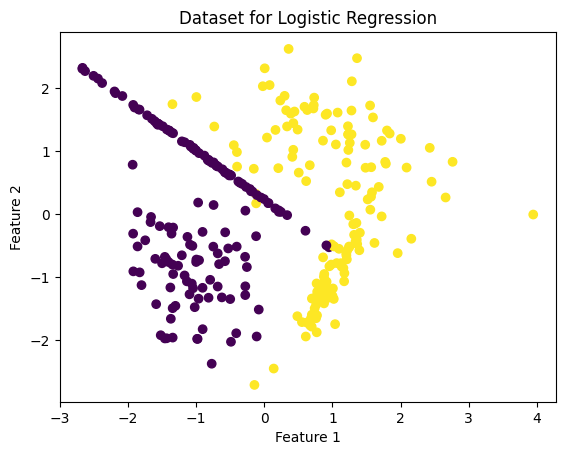

In [12]:
# Visualize dataset
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset for Logistic Regression")
plt.show()

In [13]:
# Splitting the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## **Implementing Custom Model**

In [14]:
# Custom Logistic Regression
class LogisticRegressionScratch:
    # Initializing the parameters
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
    # Sigmoid Function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Add bias term (column of ones)
        X_bias = np.hstack((np.ones((n_samples, 1)), X))

        # Initialize weights (including bias)
        self.weights = np.zeros(X_bias.shape[1])

        # Gradient descent
        for _ in range(self.n_iterations):
            linear_model = np.dot(X_bias, self.weights)
            y_pred = self.sigmoid(linear_model)

            gradient = (1 / n_samples) * np.dot(X_bias.T, (y_pred - y))
            self.weights -= self.learning_rate * gradient

    def predict(self, X):
        n_samples = X.shape[0]
        X_bias = np.hstack((np.ones((n_samples, 1)), X))  # same bias handling
        linear_model = np.dot(X_bias, self.weights)
        y_pred = self.sigmoid(linear_model)
        return np.where(y_pred >= 0.5, 1, 0)


# **Explanation of Model**

## Example Dataset
| Hours Studied | Hours Slept | Result |
|---|---|---|
| 1 | 8 | Fail (0) |
| 2 | 7 | Fail (0) |
| 5 | 6 | Pass (1) |
| 8 | 5 | Pass (1) |

---

## Step 1: Add Bias Column
A column of **1s** is prepended to X so the model can learn an intercept (bias) term.
```
X_bias = [[1, 1, 8],
          [1, 2, 7],
          [1, 5, 6],
          [1, 8, 5]]

weights = [w_bias, w1, w2] = [0, 0, 0]  ← initialized to zeros
```

---

## Step 2: Sigmoid Function
Converts any real number into a probability between 0 and 1.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- z → very large  →  σ(z) ≈ 1  (predict class 1)
- z → very small  →  σ(z) ≈ 0  (predict class 0)
- z = 0           →  σ(z) = 0.5

---

## Step 3: One Gradient Descent Iteration (Manually)

**3a. Linear combination**
```
z = X_bias · weights = [0, 0, 0, 0]   (all zeros since weights = 0)
```

**3b. Apply sigmoid → predictions**
```
y_pred = sigmoid(z) = [0.5, 0.5, 0.5, 0.5]
```

**3c. Compute error**
```
error = y_pred - y = [0.5-0, 0.5-0, 0.5-1, 0.5-1]
                   = [0.5,   0.5,  -0.5,  -0.5]
```

**3d. Compute gradient**
```
gradient = (1/n) * X_bias.T · error
         ≈ [0.0,  0.5,  0.5]
```
> Gradient tells us which direction to nudge the weights.

**3e. Update weights**
```
weights = weights - lr * gradient
        = [0,0,0] - 0.01 * [0.0, 0.5, 0.5]
        = [0.0, -0.005, -0.005]
```

---

## Step 4: Repeat for 1000 Iterations
Each iteration the weights get slightly better at separating the two classes.
```
Iteration 1   → weights ≈ [0.0,  -0.005, -0.005]
Iteration 2   → weights improve further...
...
Iteration 1000 → weights converge to optimal values
```

---

## Step 5: Final Prediction

After training:
```
Final weights ≈ [w_bias, w1, w2]

predict([1, 8]) → prob < 0.5 → Class 0 (Fail) ✓
predict([2, 7]) → prob < 0.5 → Class 0 (Fail) ✓
predict([5, 6]) → prob ≥ 0.5 → Class 1 (Pass) ✓
predict([8, 5]) → prob ≥ 0.5 → Class 1 (Pass) ✓
``` |

# **Testing Custom Model**

In [15]:
log_scratch = LogisticRegressionScratch(learning_rate=0.1, n_iterations=2000)
log_scratch.fit(X_train, y_train)
y_pred_scratch = log_scratch.predict(X_test)

print("Scratch Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_scratch))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_scratch))
print("Classification Report:\n", classification_report(y_test, y_pred_scratch))

Scratch Logistic Regression Accuracy: 0.9
Confusion Matrix:
 [[41  6]
 [ 3 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.87      0.90        47
           1       0.87      0.93      0.90        43

    accuracy                           0.90        90
   macro avg       0.90      0.90      0.90        90
weighted avg       0.90      0.90      0.90        90



# **Scikit Learn's Model**

In [16]:
from sklearn.linear_model import LogisticRegression

log_sklearn = LogisticRegression()
log_sklearn.fit(X_train, y_train)
y_pred_sklearn = log_sklearn.predict(X_test)

print("Sklearn Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_sklearn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sklearn))
print("Classification Report:\n", classification_report(y_test, y_pred_sklearn))

Sklearn Logistic Regression Accuracy: 0.9
Confusion Matrix:
 [[41  6]
 [ 3 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.87      0.90        47
           1       0.87      0.93      0.90        43

    accuracy                           0.90        90
   macro avg       0.90      0.90      0.90        90
weighted avg       0.90      0.90      0.90        90



# **Comparison between Models**

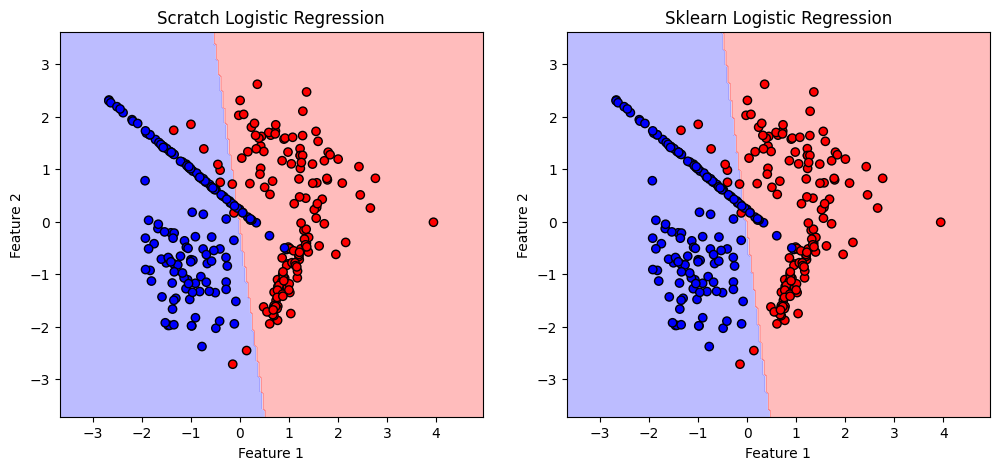

In [17]:
def plot_decision_boundary(X, y, model, title, is_scratch=True):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_scratch:
        Z = model.predict(grid)
    else:
        Z = model.predict(grid)

    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="bwr")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolor="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(X, y, log_scratch, "Scratch Logistic Regression", is_scratch=True)

plt.subplot(1, 2, 2)
plot_decision_boundary(X, y, log_sklearn, "Sklearn Logistic Regression", is_scratch=False)

plt.show()
